#### Create Word Vectors with word2vec

Load Dependencies

In [1]:
import nltk
from nltk import word_tokenize, sent_tokenize
import gensim
from gensim.models.word2vec import Word2Vec
from sklearn.manifold import TSNE
import pandas as pd
from bokeh.io import output_notebook
from bokeh.plotting import show, figure

In [3]:
nltk.download('punkt') # English sentence tokenizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\keztan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [9]:
nltk.download('punkt_tab') #sent_tokenize complained that this resource is not found

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\keztan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

Load Data

In [4]:
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\keztan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\gutenberg.zip.


True

In [2]:
from nltk.corpus import gutenberg

In [3]:
len(gutenberg.fileids())

18

In [7]:
gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

Tokenize Text

In [10]:
gberg_sent_tokens = sent_tokenize(gutenberg.raw())

In [11]:
type(gberg_sent_tokens)

list

In [13]:
len(gberg_sent_tokens)

94428

In [15]:
gberg_sent_tokens[0:6]

['[Emma by Jane Austen 1816]\n\nVOLUME I\n\nCHAPTER I\n\n\nEmma Woodhouse, handsome, clever, and rich, with a comfortable home\nand happy disposition, seemed to unite some of the best blessings\nof existence; and had lived nearly twenty-one years in the world\nwith very little to distress or vex her.',
 "She was the youngest of the two daughters of a most affectionate,\nindulgent father; and had, in consequence of her sister's marriage,\nbeen mistress of his house from a very early period.",
 'Her mother\nhad died too long ago for her to have more than an indistinct\nremembrance of her caresses; and her place had been supplied\nby an excellent woman as governess, who had fallen little short\nof a mother in affection.',
 "Sixteen years had Miss Taylor been in Mr. Woodhouse's family,\nless as a governess than a friend, very fond of both daughters,\nbut particularly of Emma.",
 'Between _them_ it was more the intimacy\nof sisters.',
 "Even before Miss Taylor had ceased to hold the nominal

In [16]:
print(gberg_sent_tokens[1])

She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.


In [17]:
word_tokenize(gberg_sent_tokens[1])

['She',
 'was',
 'the',
 'youngest',
 'of',
 'the',
 'two',
 'daughters',
 'of',
 'a',
 'most',
 'affectionate',
 ',',
 'indulgent',
 'father',
 ';',
 'and',
 'had',
 ',',
 'in',
 'consequence',
 'of',
 'her',
 'sister',
 "'s",
 'marriage',
 ',',
 'been',
 'mistress',
 'of',
 'his',
 'house',
 'from',
 'a',
 'very',
 'early',
 'period',
 '.']

In [4]:
gberg_sents = gutenberg.sents()

In [5]:
import numpy as np

In [6]:
np.shape(gberg_sents[0])

(7,)

In [7]:
gberg_sents[0:6]

[['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']'],
 ['VOLUME', 'I'],
 ['CHAPTER', 'I'],
 ['Emma',
  'Woodhouse',
  ',',
  'handsome',
  ',',
  'clever',
  ',',
  'and',
  'rich',
  ',',
  'with',
  'a',
  'comfortable',
  'home',
  'and',
  'happy',
  'disposition',
  ',',
  'seemed',
  'to',
  'unite',
  'some',
  'of',
  'the',
  'best',
  'blessings',
  'of',
  'existence',
  ';',
  'and',
  'had',
  'lived',
  'nearly',
  'twenty',
  '-',
  'one',
  'years',
  'in',
  'the',
  'world',
  'with',
  'very',
  'little',
  'to',
  'distress',
  'or',
  'vex',
  'her',
  '.'],
 ['She',
  'was',
  'the',
  'youngest',
  'of',
  'the',
  'two',
  'daughters',
  'of',
  'a',
  'most',
  'affectionate',
  ',',
  'indulgent',
  'father',
  ';',
  'and',
  'had',
  ',',
  'in',
  'consequence',
  'of',
  'her',
  'sister',
  "'",
  's',
  'marriage',
  ',',
  'been',
  'mistress',
  'of',
  'his',
  'house',
  'from',
  'a',
  'very',
  'early',
  'period',
  '.'],
 ['Her',
  'mother',
  'h

In [27]:
gberg_sents[4]

['She',
 'was',
 'the',
 'youngest',
 'of',
 'the',
 'two',
 'daughters',
 'of',
 'a',
 'most',
 'affectionate',
 ',',
 'indulgent',
 'father',
 ';',
 'and',
 'had',
 ',',
 'in',
 'consequence',
 'of',
 'her',
 'sister',
 "'",
 's',
 'marriage',
 ',',
 'been',
 'mistress',
 'of',
 'his',
 'house',
 'from',
 'a',
 'very',
 'early',
 'period',
 '.']

In [8]:
gutenberg.words()

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', ...]

In [9]:
len(gutenberg.words())

2621613

Word2Vec

In [11]:
model = Word2Vec(sentences=gberg_sents, vector_size=64, sg=1, window=10, min_count=5, workers=2)
# sg=1 is skipgram, 0 is continous bag of words(CBOW)
# it is vector_size not size
# min_count is the minimum number of times a word needs to appear to be included in the model. It affects the vocabulary size of downstream models
# my current laptop has 4 cores, so I set workers=2

In [12]:
model.save('raw_gutenberg_model.w2v')

Explore Model

In [13]:
model = gensim.models.Word2Vec.load('raw_gutenberg_model.w2v')

In [15]:
model.wv['king']

array([ 0.58038354, -0.33887026, -0.14212555,  0.4924434 , -0.0545665 ,
       -0.7558245 ,  0.24835807, -0.32828552, -0.05360548,  0.03858957,
       -0.16371013, -0.4969156 , -0.28951457, -0.00250592, -0.03667259,
        0.28178707, -0.42361164,  0.09536958, -0.15823562, -0.71553487,
       -0.06394561,  0.20769069, -0.24839123, -0.47192544, -0.18125896,
        0.02407889,  0.01644831,  0.31502298, -0.07353004, -0.07851613,
        0.10032064,  0.070544  , -0.06165746,  0.1359832 , -0.03862495,
       -0.22471723,  0.01508733, -0.10196344,  0.10138411,  0.24379663,
       -0.52775544,  0.3592784 ,  0.6038239 ,  0.37299594,  0.42600328,
       -0.28788608, -0.18293144, -0.36947852, -0.41158724,  1.3391106 ,
        0.35817984,  0.17364126,  0.00918143,  0.44934952, -0.29470965,
        0.5280074 , -0.00305876, -0.66057324, -0.24866273,  0.20751166,
       -0.03656999,  0.5293994 , -0.1131554 ,  0.32188663], dtype=float32)

In [16]:
model.wv.most_similar('dog')

[('puppy', 0.7904999256134033),
 ('thief', 0.7660647630691528),
 ('sweeper', 0.7648336291313171),
 ('chimney', 0.7539411187171936),
 ('kick', 0.7497430443763733),
 ('boy', 0.741990327835083),
 ('Tom', 0.7413316965103149),
 ('cage', 0.7358758449554443),
 ('Truck', 0.7358516454696655),
 ('butcher', 0.7350879311561584)]

In [17]:
model.wv.most_similar('think')

[('contradict', 0.8534530997276306),
 ('manage', 0.8456202745437622),
 ('suppose', 0.8345416784286499),
 ('pretend', 0.8316157460212708),
 ('know', 0.8313905596733093),
 ('Mamma', 0.8299502730369568),
 ('believe', 0.8221006393432617),
 ('behave', 0.8175557851791382),
 ('interfere', 0.8146553039550781),
 ('shouldn', 0.8146442174911499)]

In [18]:
model.wv.most_similar('day')

[('morning', 0.7837666869163513),
 ('time', 0.7496054172515869),
 ('night', 0.7473919987678528),
 ('month', 0.7438461184501648),
 ('week', 0.7255681157112122),
 ('sabbath', 0.6843873858451843),
 ('evening', 0.6823127269744873),
 ('Saturday', 0.6684605479240417),
 ('Adar', 0.6682366728782654),
 ('feasting', 0.656360387802124)]

In [19]:
model.wv.most_similar('father')

[('mother', 0.8697770237922668),
 ('brother', 0.8613248467445374),
 ('sister', 0.8214921355247498),
 ('daughter', 0.7987347841262817),
 ('wife', 0.7896643280982971),
 ('Amnon', 0.7652347087860107),
 ('uncle', 0.7507259249687195),
 ('younger', 0.7399746775627136),
 ('Tamar', 0.7289525270462036),
 ('master', 0.7188965678215027)]

In [21]:
model.wv.doesnt_match("mother father daughter".split()) 

'daughter'

In [24]:
model.wv.similarity('father', 'daughter')

0.7987348

In [ ]:
# word vector arithmetic
model.wv.most_similar(positive=['father','woman'], negative=['man'])
# hmmmm... why daughter but not mother?

[('daughter', 0.7968661785125732),
 ('husband', 0.7817797660827637),
 ('wife', 0.7761260867118835),
 ('mother', 0.7732498049736023),
 ('sister', 0.768655002117157),
 ('brother', 0.7443875074386597),
 ('younger', 0.689791738986969),
 ('Sarai', 0.6851794719696045),
 ('child', 0.6816731691360474),
 ('daughters', 0.6740225553512573)]

In [26]:
model.wv.most_similar(positive=['son','woman'], negative=['man'])

[('daughter', 0.7502760291099548),
 ('Leah', 0.728067934513092),
 ('wife', 0.7221393585205078),
 ('Abram', 0.7078531384468079),
 ('Bethuel', 0.7025447487831116),
 ('Sarai', 0.700350284576416),
 ('Hagar', 0.6999646425247192),
 ('Sarah', 0.695594072341919),
 ('Caleb', 0.6917216777801514),
 ('brother', 0.6896221041679382)]

In [27]:
model.wv.most_similar(positive=['husband','woman'], negative=['man'])

[('wife', 0.727354884147644),
 ('child', 0.694865882396698),
 ('daughter', 0.6937938928604126),
 ('sister', 0.676331639289856),
 ('mother', 0.6680704951286316),
 ('conceived', 0.6639084815979004),
 ('maid', 0.6620762348175049),
 ('widow', 0.6493308544158936),
 ('nurse', 0.647737979888916),
 ('harlot', 0.6444215774536133)]

In [29]:
model.wv.most_similar(positive=['king','woman'], negative=['man'], topn=30)

[('Sarah', 0.6913964748382568),
 ('tribute', 0.6880852580070496),
 ('Abram', 0.6859778761863708),
 ('Leah', 0.6805418729782104),
 ('Rachel', 0.6785346865653992),
 ('Babylon', 0.6731764078140259),
 ('daughter', 0.6620729565620422),
 ('Judah', 0.6564912796020508),
 ('Bethuel', 0.652623176574707),
 ('Pharaoh', 0.6516404151916504),
 ('queen', 0.6467565298080444),
 ('Vashti', 0.6462732553482056),
 ('Solomon', 0.6452773809432983),
 ('Hagar', 0.6450796127319336),
 ('Padanaram', 0.6438565254211426),
 ('Sarai', 0.6422269344329834),
 ('Laban', 0.6384049654006958),
 ('Esther', 0.6383534073829651),
 ('Hanun', 0.6380506157875061),
 ('Bilhah', 0.6350231170654297),
 ('household', 0.6256422996520996),
 ('Jerusalem', 0.6252610683441162),
 ('Hamor', 0.623532235622406),
 ('damsel', 0.6215870976448059),
 ('Samaria', 0.6203421354293823),
 ('David', 0.6201980113983154),
 ('Onan', 0.6193298101425171),
 ('Zilpah', 0.6186811923980713),
 ('Ephron', 0.6179429888725281),
 ('Rebekah', 0.6177406311035156)]

Reduce wv dimentionality with t-SNE

In [31]:
len(model.wv.key_to_index)
#vocab is removed from gensim 4.0.0

17011

In [38]:
X = model.wv[model.wv.key_to_index]

In [39]:
tsne = TSNE(n_components=2, n_iter=1000)

In [40]:
X_2d = tsne.fit_transform(X)

c:\Users\keztan\workspace\.venv\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [42]:
X_2d[0:5]

array([[-6.4777613e-01, -6.6827827e+01],
       [-2.8183544e-01, -6.5966454e+01],
       [-3.3178017e-01, -6.6270668e+01],
       [-2.6103010e+00, -6.6602989e+01],
       [-2.7630078e-02, -6.5972130e+01]], dtype=float32)

In [43]:
coords_df = pd.DataFrame(X_2d, columns=['x','y'])
coords_df['token']=model.wv.key_to_index.keys()

In [45]:
coords_df.head()

,x,y,token
0,-0.647776,-66.827827,","
1,-0.281835,-65.966454,the
2,-0.331780,-66.270668,and
3,-2.610301,-66.602989,.
4,-0.027630,-65.972130,of


In [46]:
coords_df.to_csv('raw_gutenberg_tsne.csv', index=False)

Visualize 2D representation of wv   

In [48]:
coords_df = pd.read_csv('raw_gutenberg_tsne.csv')

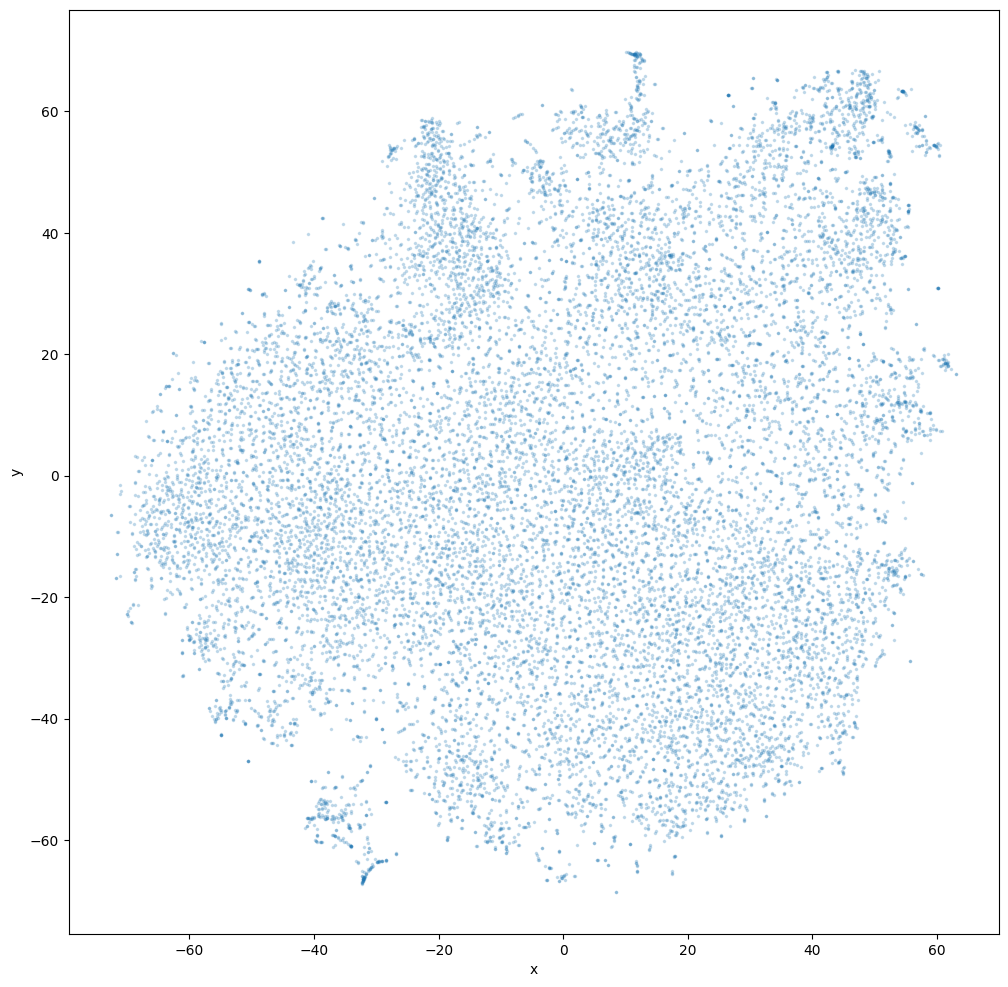

In [51]:
_ = coords_df.plot.scatter('x', 'y', figsize=(12,12),marker='.', s=10, alpha=0.2)

In [53]:
output_notebook() # need to look into this more?

Loading BokehJS ...

In [54]:
subset_df = coords_df.sample(n=5000)

In [58]:
p = figure(width=800, height=800)
_ = p.text(x=subset_df.x, y=subset_df.y, text=subset_df.token)

In [59]:
show(p)

In [60]:
type(_)

bokeh.models.renderers.glyph_renderer.GlyphRenderer

Pre-Trained Word Vectors:
1. word2vec: github.com/Kyubyong/wordvectors
2. GloVe: npl.stanford.edu/projects/glove
3. fastText: fasttext.cc
4. Francois Chollet tutorial: bit.ly/preTrained